# TinyML — Comandos de Voz: ABRIR PORTA × FECHAR PORTA

Primeira etapa do projeto para ESP32-S3.

Neste notebook vamos:

1. Fazer upload do `DATASET.zip`.
2. Localizar e validar os arquivos WAV.
3. Detectar a região da fala.
4. Preservar **200 ms antes e depois** da fala.
5. Padronizar cada entrada para **2,5 segundos**.
6. Extrair **13 coeficientes MFCC**.
7. Comparar visualmente exemplos de `ABRIR_PORTA` e `FECHAR_PORTA`.

> Nesta etapa ainda **não treinaremos o modelo**. Primeiro validaremos o pré-processamento.

## 1. Instalar/importar bibliotecas

In [ ]:
!pip -q install librosa soundfile

import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt

print("Librosa:", librosa.__version__)

Librosa: 0.11.0


## 2. Upload do DATASET.zip

In [ ]:
from google.colab import files

uploaded = files.upload()

zip_names = [name for name in uploaded.keys() if name.lower().endswith(".zip")]
if not zip_names:
    raise ValueError("Nenhum arquivo ZIP foi enviado.")

ZIP_PATH = Path("/content") / zip_names[0]
print("Arquivo recebido:", ZIP_PATH)

Saving DATASET_ELEVEN.zip to DATASET_ELEVEN.zip
Arquivo recebido: /content/DATASET_ELEVEN.zip


## 3. Extrair o dataset

In [ ]:
import zipfile
import shutil
from pathlib import Path
import librosa
import soundfile as sf

DESTINO = Path("/content/dataset")

if DESTINO.exists():
    shutil.rmtree(DESTINO)
DESTINO.mkdir(parents=True, exist_ok=True)

# Extrai o arquivo ZIP enviado
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(DESTINO)

def converter_mp3_para_wav(caminho_mp3):
    """Carrega um arquivo MP3, converte para 16kHz mono e salva como WAV PCM_16."""
    # Carrega usando librosa forçando mono e sample rate de 16000 Hz
    y, sr = librosa.load(str(caminho_mp3), sr=16000, mono=True)

    # Define o novo caminho mudando a extensão para .wav
    caminho_wav = caminho_mp3.with_suffix(".wav")

    # Salva em formato WAV de 16 bits
    sf.write(str(caminho_wav), y, sr, subtype='PCM_16')

    # Remove o arquivo MP3 original
    caminho_mp3.unlink()
    print(f"Convertido: {caminho_mp3.name} -> {caminho_wav.name}")

# Busca e converte arquivos MP3 se houver algum
arquivos_mp3 = sorted(list(DESTINO.rglob("*.mp3")) + list(DESTINO.rglob("*.MP3")))
if arquivos_mp3:
    print(f"Encontrados {len(arquivos_mp3)} arquivos MP3. Iniciando conversão...")
    for mp3_path in arquivos_mp3:
        converter_mp3_para_wav(mp3_path)

# Localiza todos os arquivos WAV pós-conversão
wav_files = sorted(list(DESTINO.rglob("*.wav")) + list(DESTINO.rglob("*.WAV")))

print(f"\nTotal de WAVs prontos para processamento: {len(wav_files)}")
for p in wav_files[:5]:
    print(p)

Encontrados 18 arquivos MP3. Iniciando conversão...
Convertido: abrir_porta (1).mp3 -> abrir_porta (1).wav
Convertido: abrir_porta (2).mp3 -> abrir_porta (2).wav
Convertido: abrir_porta (3).mp3 -> abrir_porta (3).wav
Convertido: abrir_porta (4).mp3 -> abrir_porta (4).wav
Convertido: abrir_porta (5).mp3 -> abrir_porta (5).wav
Convertido: abrir_porta (6).mp3 -> abrir_porta (6).wav
Convertido: abrir_porta (7).mp3 -> abrir_porta (7).wav
Convertido: abrir_porta (8).mp3 -> abrir_porta (8).wav
Convertido: abrir_porta (9).mp3 -> abrir_porta (9).wav
Convertido: fechar_porta (1).mp3 -> fechar_porta (1).wav
Convertido: fechar_porta (2).mp3 -> fechar_porta (2).wav
Convertido: fechar_porta (3).mp3 -> fechar_porta (3).wav
Convertido: fechar_porta (4).mp3 -> fechar_porta (4).wav
Convertido: fechar_porta (5).mp3 -> fechar_porta (5).wav
Convertido: fechar_porta (6).mp3 -> fechar_porta (6).wav
Convertido: fechar_porta (7).mp3 -> fechar_porta (7).wav
Convertido: fechar_porta (8).mp3 -> fechar_porta (8).w

## 4. Validar os arquivos WAV

In [ ]:
registros = []

for arquivo in wav_files:
    info = sf.info(str(arquivo))

    # O nome da pasta define a classe
    classe = arquivo.parent.name.upper()

    registros.append({
        "arquivo": arquivo.name,
        "classe": classe,
        "sample_rate": info.samplerate,
        "canais": info.channels,
        "duracao_s": info.duration,
        "subtype": info.subtype
    })

df = pd.DataFrame(registros)

display(df.head())
print("\nQuantidade por classe:")
display(df.groupby("classe").size().rename("quantidade"))

print("\nCaracterística: duracao_s")
display(df.groupby("classe")["duracao_s"].agg(["min", "mean", "max"]).round(3))

if len(df) != 60:
    print(f"AVISO: esperávamos 60 arquivos, mas foram encontrados {len(df)}.")

if not (df["sample_rate"] == 16000).all():
    print("AVISO: há arquivos que não estão em 16 kHz.")

if not (df["canais"] == 1).all():
    print("AVISO: há arquivos que não são mono.")

,arquivo,classe,sample_rate,canais,duracao_s,subtype
0,abrir_porta (1).wav,ABRIR_PORTA,16000,1,1.959188,PCM_16
1,abrir_porta (2).wav,ABRIR_PORTA,16000,1,2.115937,PCM_16
2,abrir_porta (3).wav,ABRIR_PORTA,16000,1,1.724125,PCM_16
3,abrir_porta (4).wav,ABRIR_PORTA,16000,1,1.802500,PCM_16
4,abrir_porta (5).wav,ABRIR_PORTA,16000,1,2.037562,PCM_16



Quantidade por classe:


,quantidade
classe,
ABRIR_PORTA,9
FECHAR_PORTA,9



Característica: duracao_s


,min,mean,max
classe,,,
ABRIR_PORTA,1.724,2.264,3.994
FECHAR_PORTA,1.724,2.264,3.234


AVISO: esperávamos 60 arquivos, mas foram encontrados 18.


## 5. Detectar a fala preservando uma margem

Não vamos eliminar todo o silêncio.

O algoritmo encontra a região principal da fala e mantém **200 ms antes e 200 ms depois**. Isso conserva uma pequena margem temporal semelhante à que existirá quando o ESP32 capturar um comando real.

In [ ]:
SR = 16000
DURACAO_JANELA = 2.5
MARGEM_S = 0.2
TOP_DB = 30

TAMANHO_JANELA = int(SR * DURACAO_JANELA)
MARGEM_AMOSTRAS = int(SR * MARGEM_S)

def recortar_fala_com_margem(y):
    # índices da região não silenciosa
    _, indice = librosa.effects.trim(y, top_db=TOP_DB)
    inicio, fim = indice

    # preserva 200 ms antes e depois
    inicio = max(0, inicio - MARGEM_AMOSTRAS)
    fim = min(len(y), fim + MARGEM_AMOSTRAS)

    return y[inicio:fim], inicio, fim

def janela_fixa(y):
    # Centraliza o sinal numa janela de 2,5 s.
    # Se for menor, adiciona zeros antes e depois.
    # Se for maior, faz corte central.
    if len(y) < TAMANHO_JANELA:
        faltam = TAMANHO_JANELA - len(y)
        esquerda = faltam // 2
        direita = faltam - esquerda
        y = np.pad(y, (esquerda, direita))
    elif len(y) > TAMANHO_JANELA:
        excesso = len(y) - TAMANHO_JANELA
        inicio = excesso // 2
        y = y[inicio:inicio + TAMANHO_JANELA]

    return y.astype(np.float32)

## 6. Ver quanto silêncio foi removido

In [ ]:
analise = []

for arquivo in wav_files:
    y, _ = librosa.load(str(arquivo), sr=SR, mono=True)

    y_recortado, inicio, fim = recortar_fala_com_margem(y)

    analise.append({
        "arquivo": arquivo.name,
        "classe": arquivo.parent.name.upper(),
        "original_s": len(y) / SR,
        "apos_trim_margem_s": len(y_recortado) / SR
    })

df_trim = pd.DataFrame(analise)

display(df_trim.head())

print("\nResumo:")
display(
    df_trim.groupby("classe")[["original_s", "apos_trim_margem_s"]]
           .agg(["min", "mean", "max"])
           .round(3)
)

,arquivo,classe,original_s,apos_trim_margem_s
0,abrir_porta (1).wav,ABRIR_PORTA,1.959188,1.959188
1,abrir_porta (2).wav,ABRIR_PORTA,2.115937,2.115937
2,abrir_porta (3).wav,ABRIR_PORTA,1.724125,1.724125
3,abrir_porta (4).wav,ABRIR_PORTA,1.802500,1.802500
4,abrir_porta (5).wav,ABRIR_PORTA,2.037562,2.037562



Resumo:


original_s               apos_trim_margem_s              
                    min   mean    max                min   mean    max
classe                                                                
ABRIR_PORTA       1.724  2.264  3.994              1.266  2.062  3.088
FECHAR_PORTA      1.724  2.264  3.234              1.456  2.100  2.954

## 7. Visualizar áudio original e região preservada

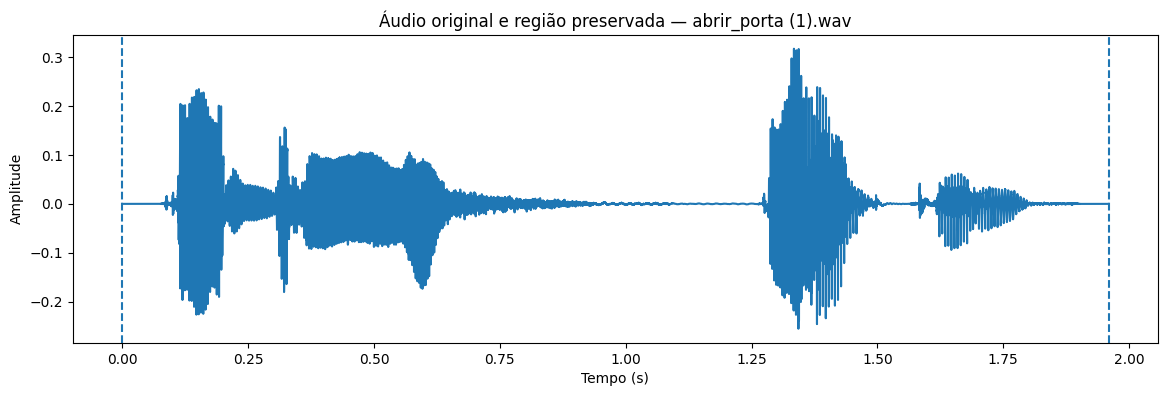

Entre as linhas tracejadas está a região que será mantida.
Ela já inclui aproximadamente 200 ms de margem antes/depois da fala.


In [ ]:
exemplo = wav_files[0]
y, _ = librosa.load(str(exemplo), sr=SR, mono=True)
y_recortado, inicio, fim = recortar_fala_com_margem(y)

tempo = np.arange(len(y)) / SR

plt.figure(figsize=(14, 4))
plt.plot(tempo, y)
plt.axvline(inicio / SR, linestyle="--")
plt.axvline(fim / SR, linestyle="--")
plt.title(f"Áudio original e região preservada — {exemplo.name}")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.show()

print("Entre as linhas tracejadas está a região que será mantida.")
print("Ela já inclui aproximadamente 200 ms de margem antes/depois da fala.")

## 8. Extrair MFCC

Usaremos:

- 16 kHz
- janela acústica de 25 ms (`400` amostras)
- deslocamento de 10 ms (`160` amostras)
- FFT de 512 pontos
- 40 filtros Mel
- 13 MFCCs

Esses parâmetros deverão ser mantidos posteriormente no ESP32 para que o pré-processamento embarcado seja compatível com o treinamento.

In [ ]:
def extrair_mfcc(y):
    return librosa.feature.mfcc(
        y=y,
        sr=SR,
        n_mfcc=13,
        n_fft=512,
        win_length=400,
        hop_length=160,
        n_mels=40,
        center=False
    ).astype(np.float32)

def processar_arquivo(arquivo):
    y, _ = librosa.load(str(arquivo), sr=SR, mono=True)
    y, _, _ = recortar_fala_com_margem(y)
    y = janela_fixa(y)
    mfcc = extrair_mfcc(y)
    return y, mfcc

## 9. Processar todos os arquivos

In [ ]:
X = []
y_labels = []
nomes = []

for arquivo in wav_files:
    audio, mfcc = processar_arquivo(arquivo)

    X.append(mfcc)
    y_labels.append(arquivo.parent.name.upper())
    nomes.append(arquivo.name)

X = np.array(X, dtype=np.float32)
y_labels = np.array(y_labels)

print("Shape de X:", X.shape)
print("Shape de y:", y_labels.shape)
print("Classes:", np.unique(y_labels))

Shape de X: (18, 13, 247)
Shape de y: (18,)
Classes: ['ABRIR_PORTA' 'FECHAR_PORTA']


### Como interpretar o `shape`

Esperamos algo semelhante a:

`(n, 13, N)`

onde:

- `n` = gravações;
- `13` = coeficientes MFCC;
- `N` = quadros temporais da janela de 2,5 segundos.

Assim, ainda preservamos a evolução da fala ao longo do tempo.

## 10. Comparar MFCC: ABRIR PORTA × FECHAR PORTA

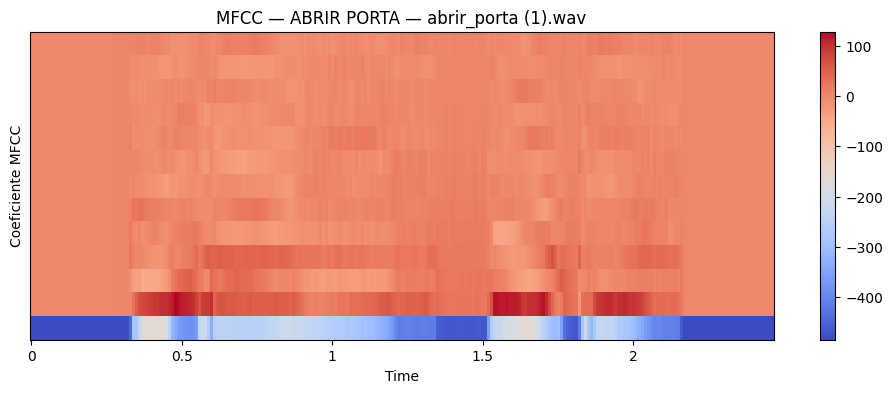

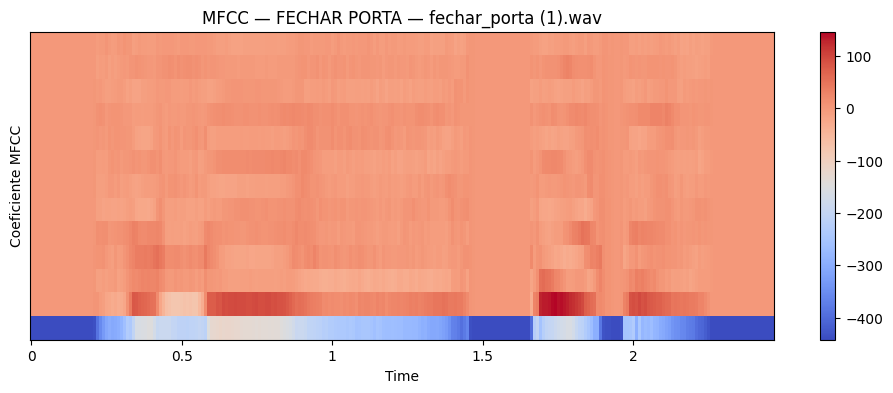

In [ ]:
idx_abrir = np.where(y_labels == "ABRIR_PORTA")[0][0]
idx_fechar = np.where(y_labels == "FECHAR_PORTA")[0][0]

mfcc_abrir = X[idx_abrir]
mfcc_fechar = X[idx_fechar]

plt.figure(figsize=(12, 4))
librosa.display.specshow(
    mfcc_abrir,
    sr=SR,
    hop_length=160,
    x_axis="time"
)
plt.colorbar()
plt.title(f"MFCC — ABRIR PORTA — {nomes[idx_abrir]}")
plt.ylabel("Coeficiente MFCC")
plt.show()

plt.figure(figsize=(12, 4))
librosa.display.specshow(
    mfcc_fechar,
    sr=SR,
    hop_length=160,
    x_axis="time"
)
plt.colorbar()
plt.title(f"MFCC — FECHAR PORTA — {nomes[idx_fechar]}")
plt.ylabel("Coeficiente MFCC")
plt.show()

## 11. Salvar o dataset MFCC intermediário

In [ ]:
saida = "/content/dataset_elevenlabs_mfcc.npz"

np.savez_compressed(
    saida,
    X=X,
    y=y_labels,
    nomes=np.array(nomes)
)

print("Arquivo salvo:", saida)
print("Tamanho:", round(os.path.getsize(saida) / 1024, 2), "KB")

Arquivo salvo: /content/dataset_elevenlabs_mfcc.npz
Tamanho: 152.87 KB


## Próxima etapa

Depois de observar os resultados deste notebook, seguiremos para:

**MFCC → divisão treino/validação/teste → modelo pequeno → avaliação → TFLite → quantização INT8 → teste do modelo quantizado.**

Não avançaremos para o treinamento antes de confirmar que o recorte e os MFCCs estão coerentes.